# <font color = blue size = 6> **Midterm Alternative (10 marks)**

# Overview:

In this homework for the midterm alternative, you will use the famous Iris dataset to explore linear regression using Python's datascience library. You will load real data, visualize relationships between variables, fit a regression line, and interpret the results.



# Learning Objectives:

- Load and explore a public dataset using the datascience Table class
- Create scatter plots with regression lines
- Calculate and interpret slope, intercept, and correlation coefficient
- Make predictions using a regression equation
- Analyze residuals to evaluate model fit


# Dataset Description
The Iris dataset is one of the most well-known datasets in data science. It contains measurements of 150 iris flowers across 3 species: setosa, versicolor, and virginica.

You can download or open Iris dataset using https://www.kaggle.com/datasets/uciml/iris .


## Setup Instructions [0 marks]

import necessary libraries

In [1]:
!pip install datascience
from datascience import *
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
%matplotlib inline

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 725.1/725.1 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 31.3 MB/s eta 0:00:00


In [2]:
from datascience import *
%matplotlib inline
#path_data = '../../../assets/data/'
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import numpy as np

Load data to a table (Use the following cell to load dataset.)

In [4]:
# Load dataset
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/iris")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'iris' dataset.
Path to dataset files: /kaggle/input/iris


In [14]:
from datascience import *
import matplotlib.pyplot as plt

# Load dataset from Kaggle path
iris_raw = Table.read_table("/kaggle/input/iris/Iris.csv")

iris = iris_raw.select(
    "SepalLengthCm",
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm",
    "Species"
).relabeled("SepalLengthCm", "sepal_length") \
 .relabeled("SepalWidthCm", "sepal_width") \
 .relabeled("PetalLengthCm", "petal_length") \
 .relabeled("PetalWidthCm", "petal_width") \
 .relabeled("Species", "species")

# Check data
iris.show(5)


sepal_length,sepal_width,petal_length,petal_width,species
5.1,3.5,1.4,0.2,Iris-setosa
4.9,3,1.4,0.2,Iris-setosa
4.7,3.2,1.3,0.2,Iris-setosa
4.6,3.1,1.5,0.2,Iris-setosa
5,3.6,1.4,0.2,Iris-setosa


# Tasks

- Use the given cells to provide your Python code.
- If the question asks for an explanation, use comment lines ('#') to provide your explanation after the code.

## <font color = blue size  = 5>**Task 1: Data Exploration (1 Mark)**

**Task Description:**

- Answer the following questions by providing appropriate Python codes


In [ ]:
# Q1. How many rows and columns does the dataset have? Print the column names.


In [16]:
print("Number of rows:", iris.num_rows)
print("Number of columns:", iris.num_columns)
print("Column names:", iris.labels)

Number of rows: 150
Number of columns: 5
Column names: ('sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species')


The dataset has 150 rows and 5 columns.
The columns are sepal_length, sepal_width, petal_length, petal_width, and species.

In [ ]:
# Q2. How many flowers are there per species? Use the .group() method.


In [15]:
# Q2
iris.group("species")

species,count
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


Each iris species appears 50 times in the dataset.
This means the dataset is balanced across the three flower classes.

In [ ]:
# Q3. Calculate the mean, minimum, and maximum of petal_length and petal_width using numpy. Show your results.


In [17]:
# Q3
petal_length = iris.column("petal_length")
petal_width = iris.column("petal_width")

print("Petal Length")
print("Mean:", np.mean(petal_length))
print("Min:", np.min(petal_length))
print("Max:", np.max(petal_length))

print("\nPetal Width")
print("Mean:", np.mean(petal_width))
print("Min:", np.min(petal_width))
print("Max:", np.max(petal_width))

Petal Length
Mean: 3.75866666667
Min: 1.0
Max: 6.9

Petal Width
Mean: 1.19866666667
Min: 0.1
Max: 2.5


Petal length ranges from 1.0 cm to 6.9 cm, with an average of 3.758 cm.
Petal width ranges from 0.1 cm to 2.5 cm, with an average of about 1.199 cm.
This shows there is good variation in flower petal sizes in the dataset.

## <font color = blue size  = 5> **Task 2: Visualization (2 Marks)**


**Task Description:**
- Answer the following questions by providing appropriate Python codes

In [ ]:
# Q4. Create a scatter plot with petal_length on the x-axis and petal_width on the y-axis. Add a title to your plot.


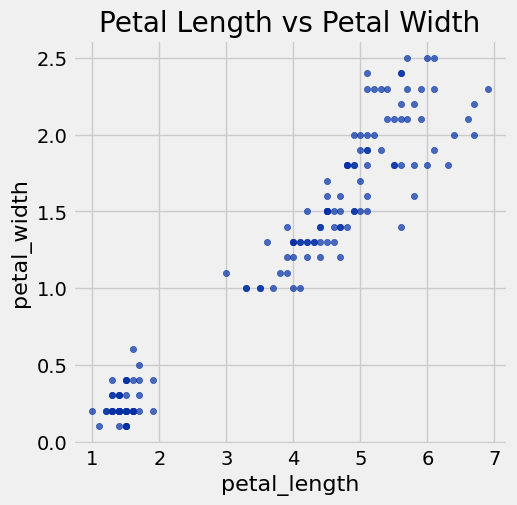

In [18]:
# Q4
iris.scatter("petal_length", "petal_width")
plt.title("Petal Length vs Petal Width")
plt.show()

In [ ]:
# Q5. Add a regression line to the scatter plot using fit_line=True. In 1-2 sentences, describe the pattern you observe between the two variables.


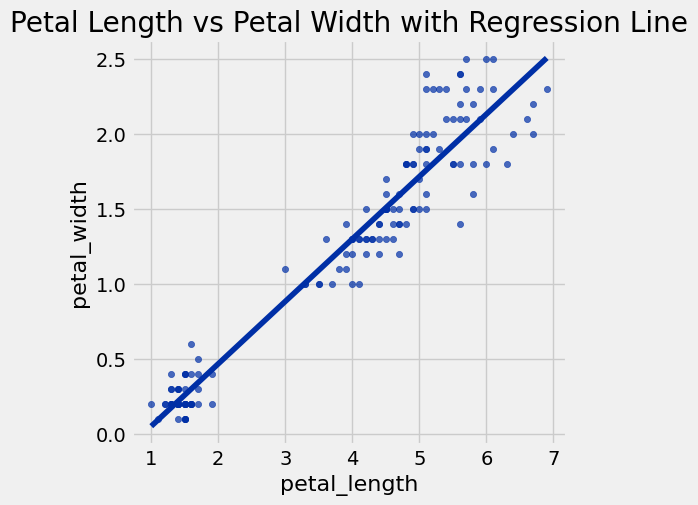

In [19]:
# Q5
iris.scatter("petal_length", "petal_width", fit_line=True)
plt.title("Petal Length vs Petal Width with Regression Line")
plt.show()

# The scatter plot shows a clear positive linear relationship between petal length and petal width.
# As petal length increases, petal width also tends to increase.

## <font color = blue size  = 5> **Task 3: Linear Regression (3 Marks)**

**Task Description:**
- Use the following helper functions in your notebook to compute the regression line
- Then answer the questions

In [21]:
def standard_units(arr):
    return (arr - np.mean(arr)) / np.std(arr)


In [22]:
def correlation(t, x, y):
    return np.mean(standard_units(t.column(x)) * standard_units(t.column(y)))


In [23]:
def slope(t, x, y):
    r = correlation(t, x, y)
    return r * np.std(t.column(y)) / np.std(t.column(x))


In [24]:
def intercept(t, x, y):
    return np.mean(t.column(y)) - slope(t, x, y) * np.mean(t.column(x))


In [ ]:
# Q6. Using the helper functions above, compute and print the slope and intercept of the regression line that predicts petal_width from petal_length. Write the full regression equation.


In [25]:
# Q6
m = slope(iris, "petal_length", "petal_width")
b = intercept(iris, "petal_length", "petal_width")

print("Slope:", m)
print("Intercept:", b)
print("Regression equation: petal_width =", m, "* petal_length +", b)

# The regression equation predicts petal width from petal length.

Slope: 0.416419132285
Intercept: -0.366514045217
Regression equation: petal_width = 0.416419132285 * petal_length + -0.366514045217


petal_width=0.4164×petal_length−0.3665

In [ ]:
# Q7. Use your regression equation to predict the petal width of a flower with petal_length = 4.5 cm. Show your calculation.


In [26]:
# Q7
x = 4.5
predicted_width = m * x + b

print("Predicted petal width for petal_length = 4.5 cm:", predicted_width)

# Calculation:
# predicted petal_width = (0.416419132285 * 4.5) - 0.366514045217


Predicted petal width for petal_length = 4.5 cm: 1.50737205007


For a flower with petal length 4.5 cm, the model predicts a petal width of about 1.5 cm.

In [ ]:
# Q8. Compute the correlation coefficient r between petal_length and petal_width. Is the relationship strong or weak? Positive or negative? Explain in 2-3 sentences.


In [27]:
r = correlation(iris, "petal_length", "petal_width")
print("Correlation coefficient r:", r)


Correlation coefficient r: 0.962757097051


The correlation coefficient is about 0.962, which indicates a very strong positive relationship.
This means flowers with longer petals usually also have wider petals.
Since the value is close to 1, the linear relationship is strong.

## <font color = blue size  = 5> **Task 4: Residual Analysis (4 Marks)**


- Use the regression line you calculated in the following questions.

In [ ]:
# Q9. Compute the predicted petal_width for every flower using your regression equation. Add both the predicted values and the residuals (actual - predicted) as new columns to the table. Display the first 8 rows.


In [28]:
predicted = iris.column("petal_length") * m + b
residuals = iris.column("petal_width") - predicted

iris_with_residuals = iris.with_columns(
    "predicted_petal_width", predicted,
    "residual", residuals
)

iris_with_residuals.show(8)

sepal_length,sepal_width,petal_length,petal_width,species,predicted_petal_width,residual
5.1,3.5,1.4,0.2,Iris-setosa,0.216473,-0.0164727
4.9,3,1.4,0.2,Iris-setosa,0.216473,-0.0164727
4.7,3.2,1.3,0.2,Iris-setosa,0.174831,0.0251692
4.6,3.1,1.5,0.2,Iris-setosa,0.258115,-0.0581147
5,3.6,1.4,0.2,Iris-setosa,0.216473,-0.0164727
5.4,3.9,1.7,0.4,Iris-setosa,0.341398,0.0586015
4.6,3.4,1.4,0.3,Iris-setosa,0.216473,0.0835273
5,3.4,1.5,0.2,Iris-setosa,0.258115,-0.0581147


In [ ]:
# Q10. Create a scatter plot of the residuals (y-axis) vs petal_length (x-axis). Add a horizontal red dashed line at y = 0. In 2-3 sentences, interpret what this plot tells you about how well the linear model fits the data.



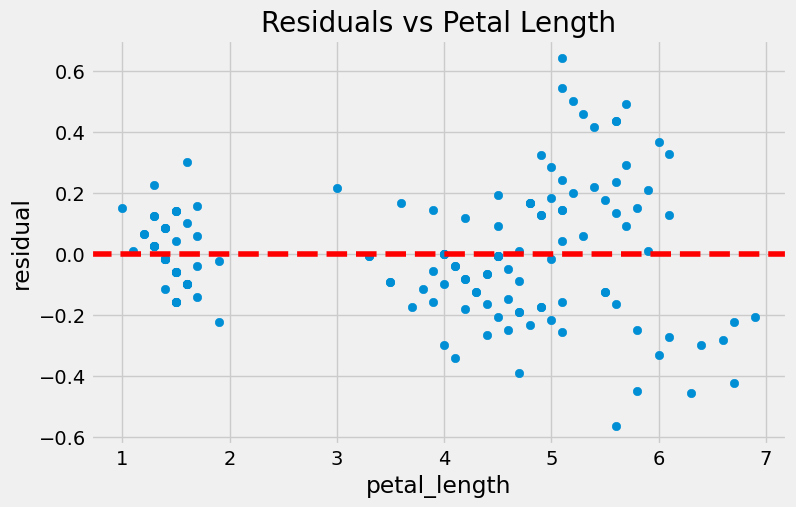

In [29]:
# Q10
plt.figure(figsize=(8,5))
plt.scatter(iris_with_residuals.column("petal_length"), iris_with_residuals.column("residual"))
plt.axhline(y=0, color='red', linestyle='dashed')
plt.xlabel("petal_length")
plt.ylabel("residual")
plt.title("Residuals vs Petal Length")
plt.show()

# The residuals are scattered around the horizontal line at zero, which suggests that the linear model fits the data reasonably well.
# There is no strong curved pattern, so a linear relationship is appropriate for these variables.
# Some spread exists, but overall the model captures the trend effectively.

# Submission Guidelines

- Make sure all cells have been run and outputs are visible before submitting.
- Name your file: FirstName_LastName_MA.ipynb
- Add a "Open in Colab" button at the top of your notebook using the following Markdown code:
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/your-repo-path/notebook.ipynb)

- Upload your completed Jupyter Notebook to a GitHub repository.
- Submit the link to your GitHub repository in the Blackboard along with the Jupyter solution file.
- <font color = red size = 6> ATTENTION!!! </font> This is an individual assessment. Students should not work on groups and the submission should be individual.  

# Grading Rubric
based on the following criteria:

- Correctness : The solution produces the expected output using the Table abstraction .
- Clarity : Code is well-organized, readable, and includes comments explaining key steps.
- Creativity : Visualizations and analyses are presented in an engaging and insightful manner.

# Hints for Success
- Use the Table abstraction methods like .select(), .where(), .group(), .apply(), and .sample() for data manipulation.
- Refer to the slides for the regression.
- Test your code frequently to ensure it runs without errors.